In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("Salary_Data.csv")

In [6]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [7]:
df.shape

(6704, 6)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [9]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [25]:
x = df[["Years of Experience"]]
y = df["Salary"]

In [14]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [26]:
x.isnull().sum()

Years of Experience    0
dtype: int64

In [27]:
y.isnull().sum()

np.int64(0)

In [28]:
df = df.dropna()

In [29]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [32]:
model = LinearRegression()
model.fit(x,y)

LinearRegression()

In [22]:
df.shape

(6698, 6)

In [23]:
print("Slope :", model.coef_[0])

Slope : 7046.734456548307


In [24]:
print("Intercept :", model.intercept_)

Intercept : 58284.685676958194


In [28]:
prediction = model.predict([[5]])

print("Predicted Salary :", prediction)

Predicted Salary : [93518.3579597]


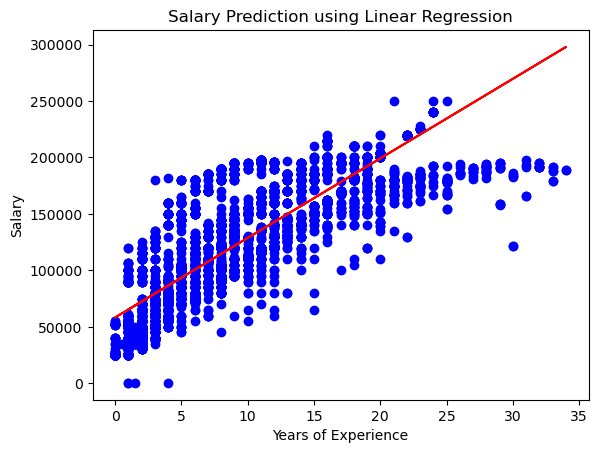

In [29]:
plt.scatter(X, y, color="blue")
plt.plot(X, model.predict(X), color="red")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Prediction using Linear Regression")
plt.show()

In [31]:
# Feature (X) and Target (Y)
X = df["Years of Experience"].values.astype(float)
Y = df["Salary"].values.astype(float)

# Number of records
n = len(X)

# Initialize parameters
m = 0.0
c = 0.0

# Hyperparameters
lr = 0.001
epochs = 20000

# Store loss values
loss_history = []

# Gradient Descent
for i in range(epochs):

    # Step 1: Predict Salary
    Y_pred = m * X + c

    # Step 2: Calculate Error
    error = Y_pred - Y

    # Step 3: Calculate Mean Squared Error (Loss)
    loss = (1 / n) * np.sum(error ** 2)
    loss_history.append(loss)

    # Step 4: Calculate Gradients
    dm = (2 / n) * np.sum(error * X)
    dc = (2 / n) * np.sum(error)

    # Step 5: Update Parameters
    m = m - lr * dm
    c = c - lr * dc

    # Print progress every 4000 epochs
    if i % 4000 == 0:
        print(f"Epoch {i}: Loss = {loss:.2f}, m = {m:.4f}, c = {c:.4f}")

# Final parameters
print("\nFinal Parameters")
print("Slope (m):", m)
print("Intercept (c):", c)

Epoch 0: Loss = 16087182745.60, m = 2384.7569, c = 230.6585
Epoch 4000: Loss = 966785462.23, m = 7308.5648, c = 54988.9414
Epoch 8000: Loss = 962891942.30, m = 7061.7885, c = 58095.1955
Epoch 12000: Loss = 962879071.40, m = 7047.6000, c = 58273.7909
Epoch 16000: Loss = 962879028.86, m = 7046.7842, c = 58284.0593

Final Parameters
Slope (m): 7046.737319820455
Intercept (c): 58284.649636008806


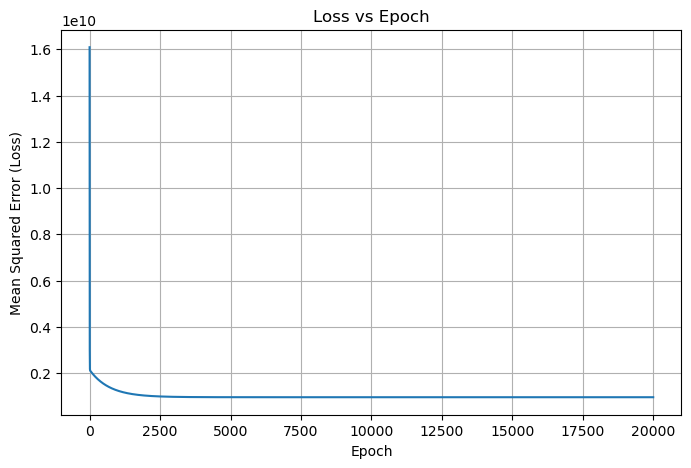

In [32]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (Loss)")
plt.grid(True)
plt.show()

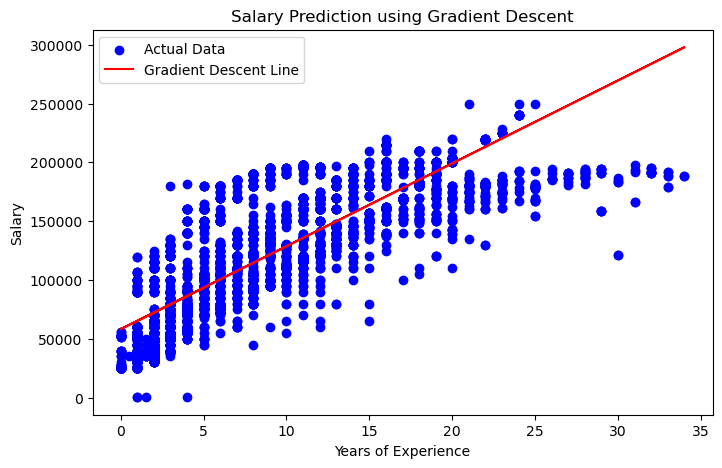

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(X, Y, color="blue", label="Actual Data")

plt.plot(X, m * X + c, color="red", label="Gradient Descent Line")

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Prediction using Gradient Descent")

plt.legend()
plt.show()

In [34]:
print("Gradient Descent")
print("Slope:", m)
print("Intercept:", c)

print("\nScikit-Learn")
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Gradient Descent
Slope: 7046.737319820455
Intercept: 58284.649636008806

Scikit-Learn
Slope: 7046.734456548307
Intercept: 58284.685676958194
